In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from pathlib import Path
import xcdat as xc
import cmasher as cmr


In [4]:
# Reload edited Python modules automatically before running subsequent cells.
%load_ext autoreload
%autoreload 2

import sys

# Add the project folder only once, even if this cell is rerun.
functions_path = "/scratch/leiff/MCA/amip_clean/project_functions/"
if functions_path not in sys.path:
    sys.path.append(functions_path)

from MCA_cov import *
from significance import *
from plotting import *
from diagnostics import *
from taylor_setup import *

In [5]:
overlap_member_residual_maps = np.load('/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/residual/overlap_member_residual_maps.npy', 
         allow_pickle=True).item()
overlap_residual_map_metadata = np.load('/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/residual/overlap_residual_map_metadata.npy', 
         allow_pickle=True).item()
overlap_model_mean_residual_maps = np.load('/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/residual/overlap_model_mean_residual_maps.npy', 
         allow_pickle=True).item()
overlap_MMM_residual_maps = np.load('/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/residual/overlap_MMM_residual_maps.npy', 
         allow_pickle=True).item()


In [6]:
# Little janky but this block gives us important common info
filepath_output_era5    = '/scratch/leiff/MCA/amip_clean/data/ERA5/tas_194001-202412_g025.nc'
ERA5                    = xc.open_dataset(filepath_output_era5).sel(time=slice('2000-03','2014-12')).rename_vars({
                            "t2m": "tas",})
ERA5['weights']         = ERA5['tas'][0]*0 + np.cos(np.deg2rad(ERA5.lat))
lat = ERA5.lat
lon = ERA5.lon

In [11]:
# %% 1. Settings and member-by-member input arrays
import numpy as np
import pandas as pd
from pathlib import Path

# Choose ONE residual diagnostic. This produces 3 spectra and 12 maps for it.
# Other examples: "corr_T_Ri", "corr_Ti_Ri", "cov_Zi_R", "cov_Zi_Ri".
# Required: overlap_member_residual_maps and overlap_residual_map_metadata.
eof_quantity = "cov_Zi_R"
eof_experiments = ["historical", "historical_matched", "amip_hist"]
eof_n_keep, eof_scree_modes = 10, 15
# Equal models: each retained member of model m gets p = 1/(M*n_m).
# Equal members: p = 1/N, reproducing the earlier ensemble-size weighting.
# Both retain every usable member and the within-model spread.
eof_sample_weighting = "equal_models"   # Or "equal_members".
eof_covariance_ddof = 1                  # 1: weighted sample convention; 0: descriptive population variance.
# With normalized sample weights p, divide covariance by 1 - ddof*sum(p**2).
# ddof=1 reduces to N-1 for equal members; it is NOT a model-dependence correction.
# ddof=0 is invariant to duplicating every member within a model under equal-model
# weighting. This setting rescales eigenvalues/regression maps, not EOF directions/fractions.
# Boolean (lat, lon) mask: True includes cells from 60°S through 60°N.
# Broadcast the latitude condition across every longitude.
within_60 = np.abs(np.asarray(lat)) <= 60
eof_spatial_mask = np.broadcast_to(within_60[:, None], (len(lat), len(lon))).copy()
# eof_spatial_mask = None                 # Optional same-grid Boolean or 1/NaN analysis mask.
eof_common_domain = True                # Use identical spatial support in all three groups.
eof_north_neff = {experiment: None for experiment in eof_experiments}
# None uses retained N for NOMINAL North bars ONLY when member weights are equal.
# Unequal weights: no bars unless you set an explicit assumed N above, e.g. 16.
# Such bars remain a sensitivity guide, not a derived unequal-weight error formula.
# Neither N_members nor N_models is a validated effective sample size here.
eof_output_dir = "/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/residual/"                  # Optional figure directory; None does not save figures.
if eof_sample_weighting not in ["equal_models", "equal_members"]:
    raise ValueError("eof_sample_weighting must be equal_models or equal_members.")

# Start from the ORIGINAL residual-fitting weights, grid, and allowed domain.
# No time detrending is repeated: each sample is an already calculated member MAP.
metadata = overlap_residual_map_metadata
eof_lat, eof_lon = [np.asarray(metadata["coordinates"][key], dtype=float) for key in ["lat", "lon"]]
eof_area_weights = np.ma.asarray(metadata["map_weights"], dtype=float).filled(np.nan)
fit_mask = np.ma.asarray(metadata["map_mask"], dtype=float).filled(np.nan)
eof_shape = (len(eof_lat), len(eof_lon))
if eof_area_weights.shape != eof_shape or fit_mask.shape != eof_shape:
    raise ValueError("Residual weights/mask must match the saved (lat, lon) grid.")
if np.any(np.isfinite(eof_area_weights) & (eof_area_weights < 0)):
    raise ValueError("Spatial area weights cannot be negative.")
eof_base_support = np.isfinite(eof_area_weights) & (eof_area_weights > 0) & np.isfinite(fit_mask) & (fit_mask != 0)
if eof_spatial_mask is not None:
    supplied_mask = np.ma.asarray(eof_spatial_mask, dtype=float).filled(np.nan)
    if supplied_mask.shape != eof_shape:
        raise ValueError("eof_spatial_mask must match (lat, lon).")
    eof_base_support &= np.isfinite(supplied_mask) & (supplied_mask != 0)
if not eof_base_support.any():
    raise ValueError("No positive-weight cells remain in the requested domain.")

# Pool members, NOT model means. Attach sample weights after excluding entirely
# missing members, so each model's count refers to members actually in the EOF.
# Preserve model, original member index, and variant label alongside every row.
eof_samples, eof_sample_index, eof_excluded_members, eof_complete_support = {}, {}, {}, {}
for experiment in eof_experiments:
    pieces, labels, excluded = [], [], []
    for model, values in overlap_member_residual_maps[experiment][eof_quantity].items():
        maps = np.ma.asarray(values, dtype=float).filled(np.nan)
        member_ids = list(metadata["member_ids"][experiment][model])
        if maps.shape != (len(member_ids),) + eof_shape:
            raise ValueError(f"{experiment}/{model}: maps and member labels have inconsistent shapes.")
        usable = np.isfinite(maps[:, eof_base_support]).any(axis=1)
        pieces.append(maps[usable])
        for member_index, member_id in enumerate(member_ids):
            record = {"model": model, "member_index": member_index, "member_id": member_id}
            if usable[member_index]:
                labels.append(record)
            else:
                excluded.append({**record, "reason": "No finite residuals on the requested domain"})

    if len(labels) < 3:
        raise ValueError(f"{experiment}: need at least 3 usable member maps for two centered modes.")
    eof_samples[experiment] = np.concatenate(pieces, axis=0)
    eof_sample_index[experiment] = pd.DataFrame(labels).rename_axis("sample")
    sample_index = eof_sample_index[experiment]
    retained_counts = sample_index.groupby("model")["model"].transform("size").to_numpy(dtype=float)
    sample_weights = 1. / retained_counts if eof_sample_weighting == "equal_models" else np.ones(len(labels))
    sample_index["sample_weight"] = sample_weights / sample_weights.sum()
    eof_excluded_members[experiment] = pd.DataFrame(
        excluded, columns=["model", "member_index", "member_id", "reason"])
    # An ordinary SVD needs complete columns. Drop any cell missing in ANY retained
    # member; do not replace missing residuals with zero or a spatial/member mean.
    eof_complete_support[experiment] = eof_base_support & np.isfinite(eof_samples[experiment]).all(axis=0)
    print(f"{experiment}: {len(labels)} members, {len(set(row['model'] for row in labels))} models; "
          f"{len(excluded)} entirely missing members excluded.")

# The default shared mask makes spatial weights and raw-EOF normalization
# directly comparable. This does NOT align or match modes across experiments.
# Restricting the domain does not refit residuals: their original spatial
# zero-mean/orthogonality conditions need not hold on this smaller mask.
common_support = np.logical_and.reduce([eof_complete_support[e] for e in eof_experiments])
eof_analysis_support = {e: (common_support.copy() if eof_common_domain else eof_complete_support[e].copy())
                        for e in eof_experiments}
for experiment, support in eof_analysis_support.items():
    if support.sum() < 2:
        raise ValueError(f"{experiment}: fewer than two complete spatial cells. Inspect missing members/masks.")
    retained_area = eof_area_weights[support].sum() / eof_area_weights[eof_base_support].sum()
    print(f"{experiment}: {support.sum()} cells; {100*retained_area:.1f}% of requested weighted area retained.")


historical: 260 members, 53 models; 0 entirely missing members excluded.
historical_matched: 142 members, 16 models; 0 entirely missing members excluded.
amip_hist: 59 members, 16 models; 0 entirely missing members excluded.
historical: 6912 cells; 100.0% of requested weighted area retained.
historical_matched: 6912 cells; 100.0% of requested weighted area retained.
amip_hist: 6912 cells; 100.0% of requested weighted area retained.


In [12]:
# %% 2. Area-weighted covariance EOFs and regression onto standardized member PCs
def residual_member_eofs(maps, weights, support, n_keep=10, north_neff=None):
    """EOFs across equally weighted member maps; sample axis is NOT time.

    Remove the pooled-member mean at each cell, but do not remove each model's
    own mean, standardize grid cells, or normalize each map's residual amplitude.
    'eofs' are spatial directions with unit AREA-weighted norm, after removing
    the sqrt(area) factors from the SVD vectors. 'eofs_weighted' retains those
    vectors as returned by the weighted SVD, for numerical inspection.
    """
    maps = np.ma.asarray(maps, dtype=float).filled(np.nan)
    weights, support = np.asarray(weights, dtype=float), np.asarray(support, dtype=bool)
    if maps.ndim != 3 or weights.shape != maps.shape[1:] or support.shape != weights.shape:
        raise ValueError("Use maps=(member, lat, lon), with weights/support=(lat, lon).")
    n_samples, spatial_shape = maps.shape[0], maps.shape[1:]
    if n_samples < 3 or support.sum() < 2:
        raise ValueError("Need at least three members and two spatial cells.")
    if not isinstance(n_keep, (int, np.integer)) or n_keep < 2:
        raise ValueError("n_keep must be an integer of at least two.")
    field = maps[:, support]
    w = weights[support]
    if not np.isfinite(field).all() or not np.isfinite(w).all() or np.any(w <= 0):
        raise ValueError("Selected cells must be complete with positive finite weights.")
    if not np.any(np.ptp(field, axis=0) > 0):
        raise ValueError("All member maps are identical on the analysis domain; no covariance EOFs exist.")
    w = w / w.max()
    w = w / w.sum()
    sqrt_w = np.sqrt(w)

    # Center across MEMBERS at each location. The saved sample_mean_map is pooled
    # by member and is generally NOT your model-weighted residual MMM.
    sample_mean = field.mean(axis=0)
    anomalies = field - sample_mean
    weighted_anomalies = anomalies * sqrt_w[None, :]
    U, singular_values, Vt = np.linalg.svd(weighted_anomalies, full_matrices=False)

    # Sample covariance uses N-1. Keep the FULL available eigenvalue spectrum so
    # explained fractions are normalized by total variance, not just kept modes.
    max_rank = min(n_samples - 1, field.shape[1])
    eigenvalues = singular_values[:max_rank]**2 / (n_samples - 1)
    total_variance = eigenvalues.sum()
    tolerance = np.finfo(float).eps * max(weighted_anomalies.shape) * singular_values[0]
    numerical_rank = min(max_rank, int(np.sum(singular_values > tolerance)))
    if numerical_rank == 0 or not np.isfinite(total_variance) or total_variance <= 0:
        raise ValueError("No numerically resolved, finite residual variance remains.")
    k = min(n_keep, numerical_rank)
    variance_fraction = eigenvalues / total_variance

    # EOF signs are arbitrary. Set the largest-magnitude weighted loading positive,
    # flipping the PC with its EOF. This is reproducibility, NOT cross-experiment
    # mode matching; near-degenerate modes can also rotate or exchange rank.
    weighted_eofs = Vt[:k].copy()
    anchors = np.argmax(np.abs(weighted_eofs), axis=1)
    signs = np.where(weighted_eofs[np.arange(k), anchors] >= 0, 1., -1.)
    weighted_eofs *= signs[:, None]
    eofs = weighted_eofs / sqrt_w[None, :]
    pcs = U[:, :k] * singular_values[None, :k] * signs[None, :]

    # PCs have one value per MEMBER, not a monthly time series. Unit-variance PCs
    # use the same N-1 convention as eigenvalues and covariance/regression.
    pc_sd = np.sqrt(eigenvalues[:k])
    pcs_standardized = pcs / pc_sd[None, :]
    regression = pcs_standardized.T @ anomalies / (n_samples - 1)
    # Thus beta_k(i) = sqrt(lambda_k) * EOF_k(i): the same shape, with mode
    # amplitude restored in residual-map units per one SD of the member PC.
    np.testing.assert_allclose((pcs_standardized.T @ pcs_standardized)/(n_samples - 1),
                               np.eye(k), rtol=1e-9, atol=1e-9)
    np.testing.assert_allclose((eofs*w[None, :]) @ eofs.T, np.eye(k), rtol=1e-9, atol=1e-9)
    np.testing.assert_allclose(regression / pc_sd[:, None], eofs, rtol=1e-8, atol=1e-8)

    # North's approximate eigenvalue error scale. Member/model dependence is NOT
    # estimated here. Optional effective N is an explicit sensitivity assumption.
    north_n = float(n_samples if north_neff is None else north_neff)
    if not np.isfinite(north_n) or not 2 <= north_n <= n_samples:
        raise ValueError("North's assumed sample size must lie between 2 and the retained member count.")
    north_error = eigenvalues * np.sqrt(2. / north_n)

    # Restore geographic shapes; excluded cells stay NaN, never arbitrary zeros.
    eof_maps, weighted_maps, regression_maps = [np.full((k,) + spatial_shape, np.nan) for _ in range(3)]
    eof_maps[:, support], weighted_maps[:, support] = eofs, weighted_eofs
    regression_maps[:, support] = regression
    mean_map, analysis_weights = np.full(spatial_shape, np.nan), np.zeros(spatial_shape)
    mean_map[support], analysis_weights[support] = sample_mean, w
    return {
        "eofs": eof_maps, "eofs_weighted": weighted_maps, "regression_maps": regression_maps,
        "pcs": pcs, "pcs_standardized": pcs_standardized, "pc_sd": pc_sd,
        "eigenvalues": eigenvalues, "variance_fraction": variance_fraction, "total_variance": total_variance,
        "north_error_eigenvalue": north_error, "north_error_fraction": north_error / total_variance,
        "north_n": north_n, "north_n_is_nominal": north_neff is None,
        "sample_mean_map": mean_map, "weights": analysis_weights, "spatial_mask": support.copy(),
        "n_samples": n_samples, "n_modes_kept": k, "numerical_rank": numerical_rank, "ddof": 1,
    }


# Preserve previously computed quantities when rerunning with a different selector.
# Uncomment the reset line if you intentionally want to discard earlier results.
# overlap_residual_eofs = {}
if "overlap_residual_eofs" not in globals():
    overlap_residual_eofs = {}
for experiment in eof_experiments:
    print(f"Fitting {experiment} / {eof_quantity} ...", flush=True)
    result = residual_member_eofs(eof_samples[experiment], eof_area_weights, eof_analysis_support[experiment],
                                  n_keep=eof_n_keep, north_neff=eof_north_neff[experiment])
    sample_index = eof_sample_index[experiment].copy()
    pc_table = sample_index.copy()
    for mode in range(result["n_modes_kept"]):
        pc_table[f"PC{mode+1}"] = result["pcs"][:, mode]
        pc_table[f"PC{mode+1}_std"] = result["pcs_standardized"][:, mode]
    result.update({
        "quantity": eof_quantity, "units": metadata["quantity_info"][eof_quantity]["units"],
        "lat": eof_lat.copy(), "lon": eof_lon.copy(), "sample_index": sample_index, "pc_table": pc_table,
        "excluded_members": eof_excluded_members[experiment].copy(),
        "model_member_counts": sample_index["model"].value_counts(sort=False).to_dict(),
        "n_models": sample_index["model"].nunique(), "common_domain": eof_common_domain,
        "sample_weighting": "Equal members; models with more members contribute more",
        "centering": "Pooled-member mean map removed; model-mean differences retained",
        "field_scaling": "No gridpoint-SD or per-map amplitude standardization",
        "north_note": "Nominal independent-sample error scale, or user-assumed effective N; not a cluster-calibrated CI",
    })
    overlap_residual_eofs.setdefault(experiment, {})[eof_quantity] = result
    print(f"  Kept {result['n_modes_kept']} modes; first two variance fractions: "
          f"{np.round(100*result['variance_fraction'][:2], 2)}%")
# Large temporary input stacks may be released after inspecting them: del eof_samples


Fitting historical / cov_Zi_R ...


  Kept 10 modes; first two variance fractions: [25.62 17.53]%
Fitting historical_matched / cov_Zi_R ...
  Kept 10 modes; first two variance fractions: [25.14  8.46]%
Fitting amip_hist / cov_Zi_R ...
  Kept 10 modes; first two variance fractions: [17.57 11.63]%


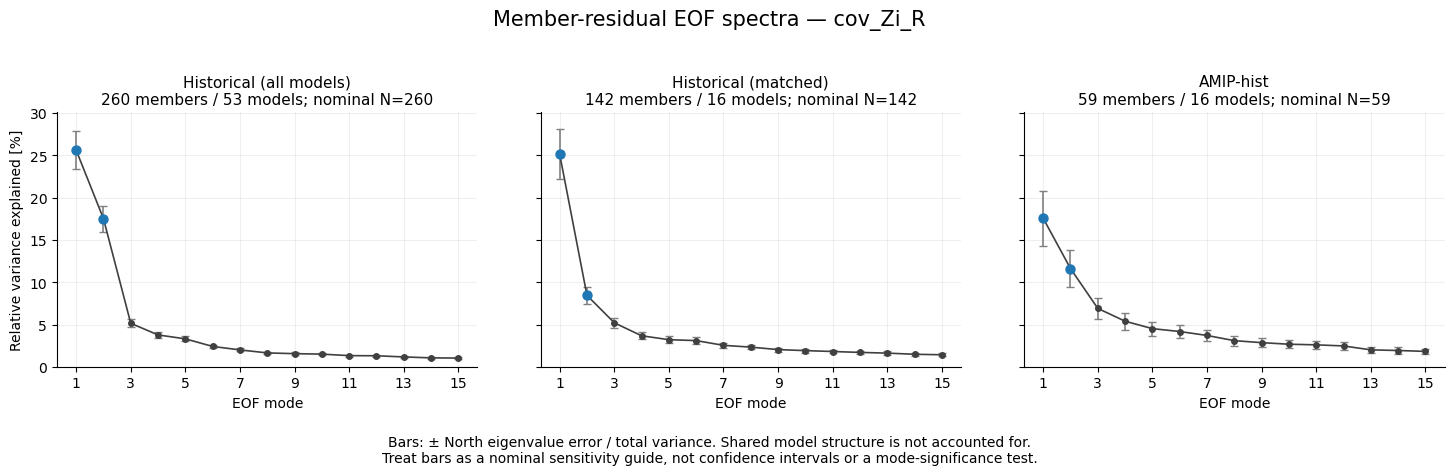

In [13]:
# %% 3. Three relative-variance spectra with clearly labelled North-style bars
import matplotlib.pyplot as plt

experiment_titles = {"historical": "Historical (all models)",
                     "historical_matched": "Historical (matched)", "amip_hist": "AMIP-hist"}
fig_eof_spectra, axes_eof_spectra = plt.subplots(1, 3, figsize=(15, 4.9), sharey=True)
fig_eof_spectra.subplots_adjust(left=.065, right=.99, bottom=.24, top=.76, wspace=.15)

# Fractions refer to area-weighted variance ACROSS member residual maps around
# their pooled mean, not temporal variance or the original map-fit residual fraction.
# North: delta(lambda_k) ~= lambda_k*sqrt(2/N). Dividing by the observed total
# puts that eigenvalue error scale on a percentage axis. It is NOT a calibrated
# confidence interval for variance fractions, nor a correction for model families.
# Source: North et al. (1982), via NCAR eofunc_north documentation (Eq. 24,
# Description and Example 1); source consultation is recorded in the bibliography.
spectrum_upper = 0.
for ax, experiment in zip(axes_eof_spectra, eof_experiments):
    result = overlap_residual_eofs[experiment][eof_quantity]
    count = min(eof_scree_modes, len(result["eigenvalues"]))
    mode_numbers = np.arange(1, count + 1)
    percent = 100 * result["variance_fraction"][:count]
    error = 100 * result["north_error_fraction"][:count]
    spectrum_upper = max(spectrum_upper, float(np.max(percent + error)))
    ax.errorbar(mode_numbers, percent, yerr=error, fmt="o-", color="0.25",
                ecolor="0.5", markersize=4, linewidth=1.2, capsize=3)
    ax.scatter(mode_numbers[:2], percent[:2], s=42, color="tab:blue", zorder=4)
    assumption = "nominal N" if result["north_n_is_nominal"] else "assumed effective N"
    ax.set_title(f"{experiment_titles[experiment]}\n"
                 f"{result['n_samples']} members / {result['n_models']} models; {assumption}={result['north_n']:g}",
                 fontsize=11)
    ax.set(xlabel="EOF mode", ylim=(0, None))
    ax.set_xticks(mode_numbers[::max(1, int(np.ceil(count/10)))])
    ax.grid(alpha=.2)
    ax.spines[["top", "right"]].set_visible(False)
# Set the shared upper bound AFTER reading every group, so later/larger bars
# are not clipped by the first panel. Nominal eigenvalue bars may exceed 100%.
axes_eof_spectra[0].set_ylim(0, max(1., 1.07*spectrum_upper))
axes_eof_spectra[0].set_ylabel("Relative variance explained [%]")
fig_eof_spectra.suptitle(f"Member-residual EOF spectra — {eof_quantity}", fontsize=15, y=.97)
fig_eof_spectra.text(.5, .04,
    "Bars: ± North eigenvalue error / total variance. Shared model structure is not accounted for.\n"
    "Treat bars as a nominal sensitivity guide, not confidence intervals or a mode-significance test.",
    ha="center", va="bottom", fontsize=10)
if eof_output_dir is not None:
    output_dir = Path(eof_output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    fig_eof_spectra.savefig(output_dir / f"residual_eof_spectra_{eof_quantity}.png", dpi=200, bbox_inches="tight")
plt.show()


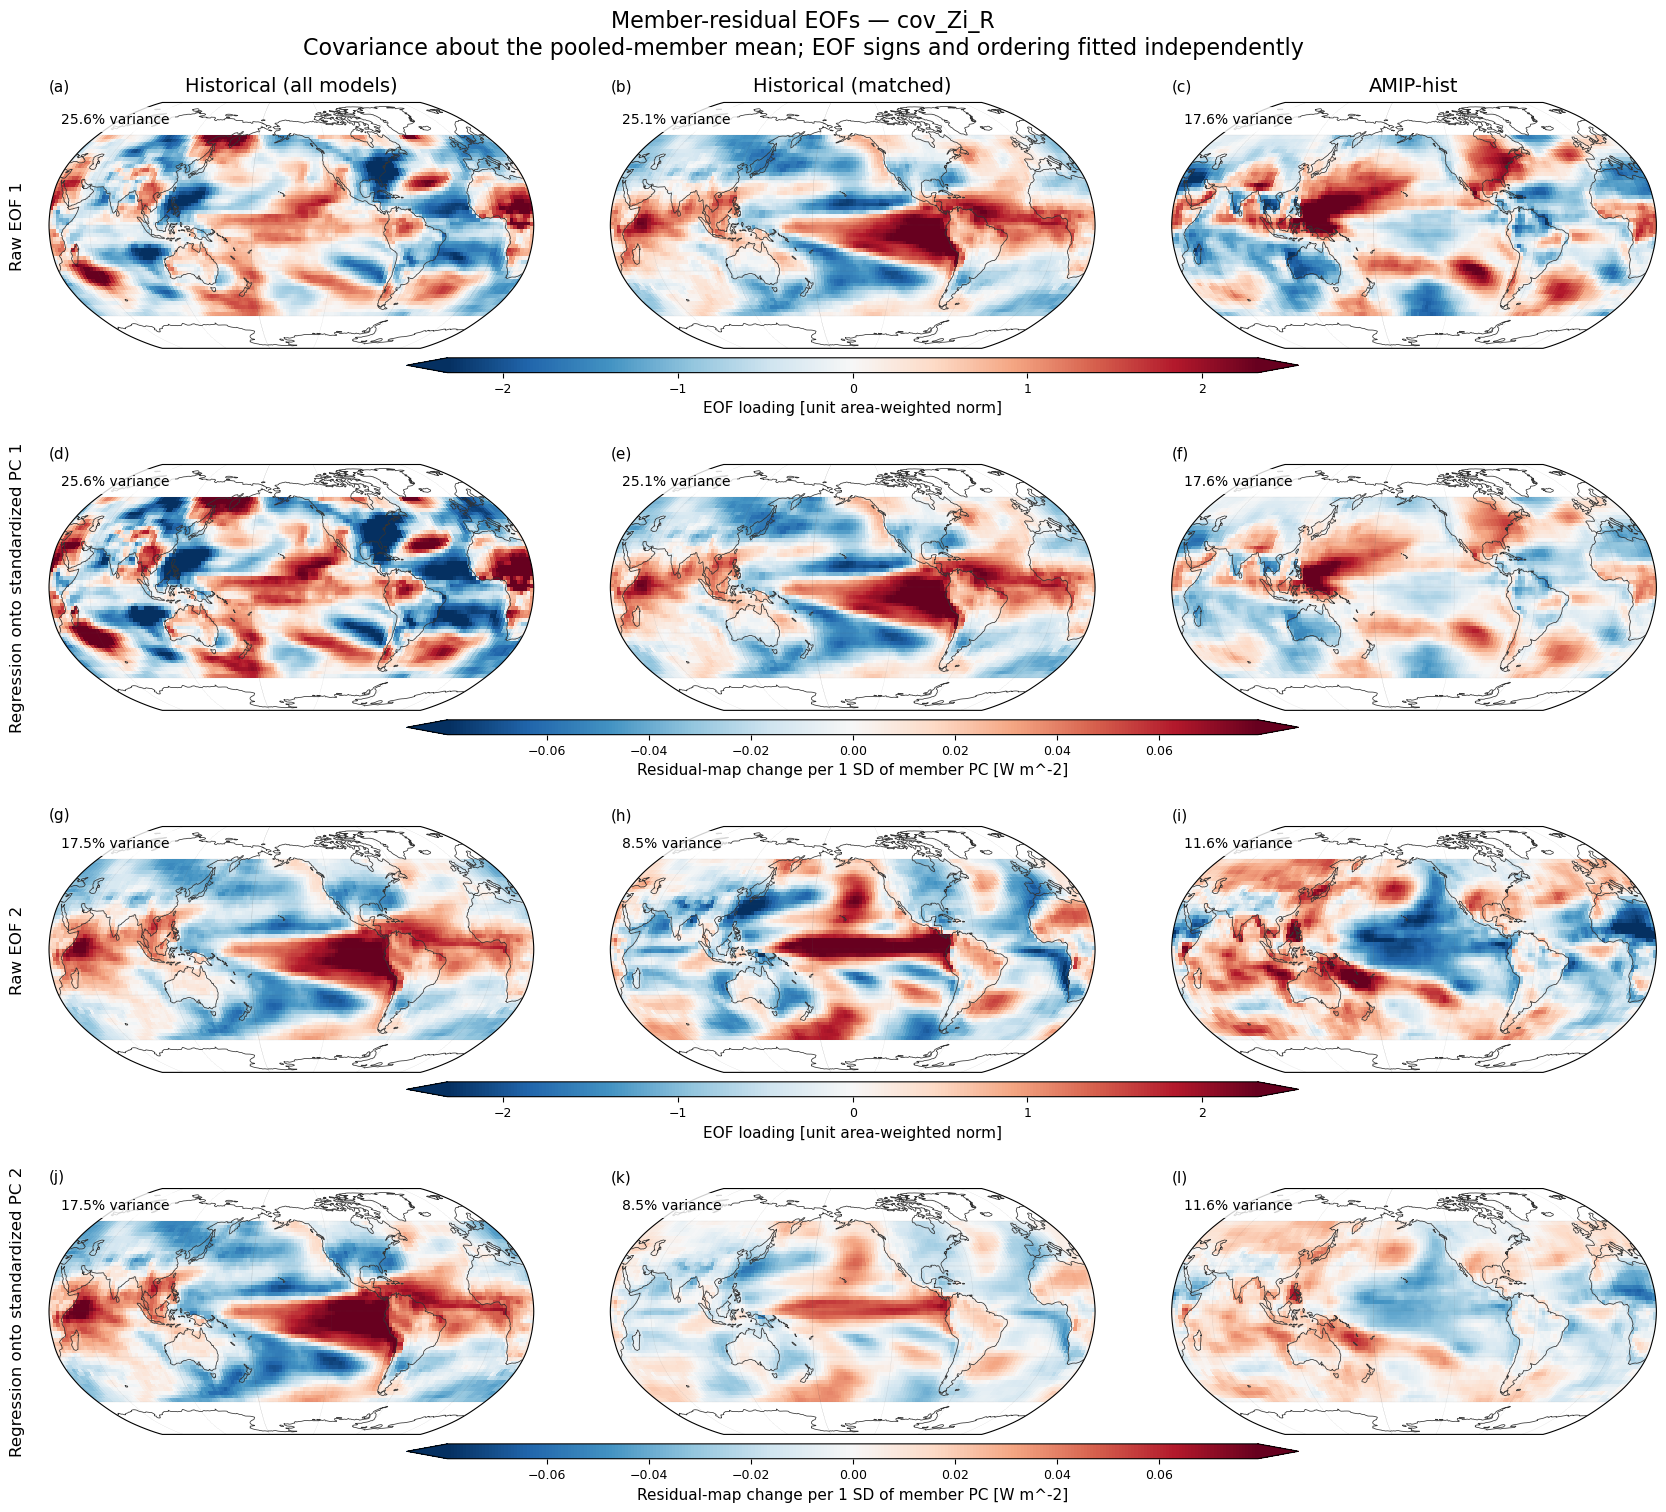

In [14]:
# %% 4. Twelve maps: raw EOF and standardized-PC regression for modes 1 and 2
import matplotlib as mpl
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import warnings

# Columns are experiments. Rows are raw EOF1, regression PC1*, raw EOF2,
# regression PC2*. All RAW panels share one scale; all REGRESSION panels share
# another. This makes amplitudes comparable across modes as well as experiments.
# Raw maps have unit area-weighted norm; regression maps restore mode amplitude.
eof_map_cmap = "RdBu_r"                  # Or "cmr.fusion_r" after importing cmasher.
eof_raw_vlim, eof_regression_vlim = None, None
eof_map_percentile = 98
eof_plot_method = "pcolormesh"           # Or "contourf".
eof_central_longitude = 210
if eof_plot_method not in ["pcolormesh", "contourf"]:
    raise ValueError("eof_plot_method must be pcolormesh or contourf.")
if not 0 < eof_map_percentile <= 100:
    raise ValueError("eof_map_percentile must be in (0, 100].")

# A rank-one experiment has no second resolved mode. Retain its panel position
# but mark it undefined instead of inventing a second PC or zero-valued EOF.
eof_map_grid = np.full((4, 3) + eof_shape, np.nan)
for column, experiment in enumerate(eof_experiments):
    result = overlap_residual_eofs[experiment][eof_quantity]
    for mode in range(min(2, result["n_modes_kept"])):
        eof_map_grid[2*mode, column] = result["eofs"][mode]
        eof_map_grid[2*mode+1, column] = result["regression_maps"][mode]

eof_map_limits = {}
for name, rows, manual_limit in [("raw", [0, 2], eof_raw_vlim),
                                  ("regression", [1, 3], eof_regression_vlim)]:
    values = np.abs(eof_map_grid[rows])
    finite = values[np.isfinite(values)]
    if not finite.size:
        raise ValueError(f"No finite {name} maps are available.")
    limit = float(np.percentile(finite, eof_map_percentile)) if manual_limit is None else float(manual_limit)
    if manual_limit is None and limit == 0:
        limit = float(finite.max()) if finite.max() > 0 else 1.
    if not np.isfinite(limit) or limit <= 0:
        raise ValueError("Manual map limits must be positive and finite.")
    eof_map_limits[name] = limit

units = metadata["quantity_info"][eof_quantity]["units"]
units_label = "dimensionless" if units == "1" else units
row_titles = ["Raw EOF 1", "Regression onto standardized PC 1", "Raw EOF 2", "Regression onto standardized PC 2"]
row_colorbar_labels = ["EOF loading [unit area-weighted norm]",
                      f"Residual-map change per 1 SD of member PC [{units_label}]"] * 2
cyclic = np.isclose(abs(eof_lon[-1] - eof_lon[0]), 360.)
fig_eof_maps, axes_eof_maps = plt.subplots(4, 3, figsize=(18, 15.5),
    subplot_kw={"projection": ccrs.Robinson(central_longitude=eof_central_longitude)})
fig_eof_maps.subplots_adjust(left=.065, right=.99, top=.92, bottom=.045, wspace=.035, hspace=.34)

for row in range(4):
    kind, mode = ("raw" if row % 2 == 0 else "regression"), row // 2
    limit = eof_map_limits[kind]
    norm, levels = mpl.colors.Normalize(-limit, limit), np.linspace(-limit, limit, 21)
    mappable = mpl.cm.ScalarMappable(norm=norm, cmap=eof_map_cmap)
    for column, experiment in enumerate(eof_experiments):
        result, ax = overlap_residual_eofs[experiment][eof_quantity], axes_eof_maps[row, column]
        panel = eof_map_grid[row, column]
        if mode < result["n_modes_kept"]:
            values, longitude = (panel, eof_lon) if cyclic else add_cyclic_point(panel, coord=eof_lon, axis=-1)
            contours_drawn = False
            if eof_plot_method == "contourf":
                before_contours = list(ax.collections)
                try:
                    mappable = ax.contourf(longitude, eof_lat, np.ma.masked_invalid(values), levels=levels,
                        norm=norm, cmap=eof_map_cmap, extend="both", transform=ccrs.PlateCarree())
                    contours_drawn = True
                except TypeError as error:
                    # Narrow workaround for the Cartopy/Shapely contour seam issue.
                    # Warn and retain the same numerical values and color norm.
                    if "GeometryCollection" not in str(error):
                        raise
                    for artist in list(ax.collections):
                        if artist not in before_contours:
                            artist.remove()
                    warnings.warn(f"EOF panel {row+1},{column+1}: contour geometry failed; using pcolormesh.")
            if not contours_drawn:
                mappable = ax.pcolormesh(longitude, eof_lat, np.ma.masked_invalid(values), shading="auto",
                    norm=norm, cmap=eof_map_cmap, transform=ccrs.PlateCarree(), rasterized=True)
            ax.text(.025, .96, f"{100*result['variance_fraction'][mode]:.1f}% variance",
                    transform=ax.transAxes, ha="left", va="top", fontsize=10,
                    bbox=dict(facecolor="white", edgecolor="none", alpha=.8), zorder=6)
        else:
            ax.text(.5, .5, "Second mode undefined\n(numerical rank < 2)",
                    transform=ax.transAxes, ha="center", va="center", fontsize=11)
        ax.set_global()
        ax.coastlines(resolution="110m", linewidth=.55, color="0.2", zorder=5)
        ax.gridlines(linewidth=.3, color="0.35", alpha=.4, linestyle=":")
        ax.set_title(f"({chr(ord('a')+row*3+column)})", loc="left", fontsize=11, pad=5)
        if row == 0:
            ax.set_title(experiment_titles[experiment], fontsize=14, pad=8)
    axes_eof_maps[row, 0].text(-.065, .5, row_titles[row], transform=axes_eof_maps[row, 0].transAxes,
                               rotation=90, ha="center", va="center", fontsize=12)
    colorbar = fig_eof_maps.colorbar(mappable, ax=list(axes_eof_maps[row]), orientation="horizontal",
                                    pad=.035, fraction=.055, aspect=60, shrink=.8, extend="both")
    colorbar.set_label(row_colorbar_labels[row], fontsize=11)
    colorbar.ax.tick_params(labelsize=9)
fig_eof_maps.suptitle(f"Member-residual EOFs — {eof_quantity}\n"
                     "Covariance about the pooled-member mean; EOF signs and ordering fitted independently",
                     fontsize=16)
if eof_output_dir is not None:
    output_dir = Path(eof_output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    fig_eof_maps.savefig(output_dir / f"residual_eof_maps_{eof_quantity}.png", dpi=200, bbox_inches="tight")
plt.show()

# Inspect coefficients by model/member, or reconstruct a retained-mode approximation:
# result = overlap_residual_eofs["historical_matched"][eof_quantity]
# display(result["pc_table"])
# approximate = result["sample_mean_map"] + np.einsum("mk,kij->mij", result["pcs"], result["eofs"])
# No original-map gain or offset is added back: these remain residual-space fields.
